# 05 · Cleaning & an Interpretable Risk-Factor Model
### Credit Risk Analysis

**Notebook 5 of 6.** The EDA notebooks (03, 04) looked at one factor at a time.
This notebook does two things: it **cleans and engineers** the features into a
model-ready form, then fits a single, **interpretable model** to ask a sharper
question — *holding everything else constant, how much does each factor move the
risk?*

**A deliberate framing.** As established when we scoped this project, the
applicant features here are weak predictors of an engineered default label, so
the goal of this model is **explanation, not a high accuracy score**. We use
logistic regression precisely because its coefficients translate into
**odds ratios** a stakeholder can read ("group X has ~1.4x the odds of going
bad"). We report honest performance metrics, but the headline output is a ranked,
signed list of risk drivers — not a leaderboard number.

## 1. Setup and load the labelled data

**What:** Load the labelled base table from notebook 02 and import the
scikit-learn pieces we will use.

**Why:** Re-using the saved labelled table guarantees the model is trained on the
exact target we engineered and analyzed, with no risk of definition drift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("../data/processed/credit_risk_labelled.csv")
print(f"Loaded {len(df):,} labelled clients | bad rate = {df['target'].mean()*100:.2f}%")

Loaded 36,457 labelled clients | bad rate = 1.69%


## 2. Clean and engineer features

**What:** Turn the raw columns into model-ready features:

- **Decode** `DAYS_BIRTH` -> `age_years`; `DAYS_EMPLOYED` -> `employ_years` with an
  `is_employed` flag (the positive sentinel = not employed -> 0 years).
- **Tame skew / scale:** `log_income` = log of annual income; `income_per_member`
  = income / family size.
- **Handle missing:** fill missing `OCCUPATION_TYPE` with the explicit category
  `"Unknown"` (rather than dropping ~30% of rows).
- **Drop dead weight:** remove `FLAG_MOBIL` (constant — zero variance) and the raw
  day/ID columns we have replaced.

**Why:** Each step addresses a specific issue found in notebook 01 — the encoded
date fields, the income skew, the large `OCCUPATION_TYPE` gap, and the
zero-variance flag. Treating "missing occupation" as its own category preserves
the rows *and* lets the model learn whether missingness itself carries signal.

In [2]:
data = df.copy()

# Decode age & employment
data["age_years"] = (-data["DAYS_BIRTH"] / 365.25).round(2)
data["is_employed"] = (data["DAYS_EMPLOYED"] < 0).astype(int)
data["employ_years"] = np.where(data["is_employed"] == 1,
                                -data["DAYS_EMPLOYED"] / 365.25, 0).round(2)

# Financial transforms
data["log_income"] = np.log1p(data["AMT_INCOME_TOTAL"])
data["income_per_member"] = (data["AMT_INCOME_TOTAL"] /
                             data["CNT_FAM_MEMBERS"].replace(0, 1))

# Missing occupation -> explicit category
data["OCCUPATION_TYPE"] = data["OCCUPATION_TYPE"].fillna("Unknown")

numeric_features = ["age_years", "employ_years", "is_employed", "log_income",
                    "income_per_member", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
                    "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"]
categorical_features = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
                        "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
                        "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]

X = data[numeric_features + categorical_features]
y = data["target"]
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(numeric_features)} numeric, {len(categorical_features)} categorical)")
print("Dropped: ID, DAYS_BIRTH, DAYS_EMPLOYED, AMT_INCOME_TOTAL (replaced), FLAG_MOBIL (constant)")

Feature matrix: 36,457 rows x 18 columns (10 numeric, 8 categorical)
Dropped: ID, DAYS_BIRTH, DAYS_EMPLOYED, AMT_INCOME_TOTAL (replaced), FLAG_MOBIL (constant)


## 3. Train/test split and preprocessing pipeline

**What:** Split into train and test sets with **stratification** on the target,
then build a preprocessing pipeline that standardizes numeric features and
one-hot-encodes categoricals.

**Why:** Stratifying preserves the ~1.7% bad rate in both splits — essential with
a rare target, or the test set could end up with almost no positives. Wrapping
preprocessing in a `Pipeline` prevents leakage (the scaler/encoder are fit on
train only) and makes the whole model a single reproducible object we can save.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
])
print(f"Train: {X_train.shape[0]:,} rows ({y_train.mean()*100:.2f}% bad)")
print(f"Test:  {X_test.shape[0]:,} rows ({y_test.mean()*100:.2f}% bad)")

Train: 27,342 rows (1.69% bad)
Test:  9,115 rows (1.69% bad)


## 4. Fit logistic regression with balanced class weights

**What:** Fit a logistic regression inside the pipeline, using
`class_weight="balanced"`.

**Why:** Logistic regression is the **interpretable** workhorse of credit scoring
— its coefficients map directly to odds ratios, which is exactly what we want for
explanation (and is the basis of a real scorecard). `class_weight="balanced"`
tells the model to pay proportionally more attention to the rare "bad" cases, so
it does not simply learn to call everyone "good".

In [4]:
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])
model.fit(X_train, y_train)
print("Model fitted.")

Model fitted.


## 5. Evaluate — with the *right* metrics, honestly

**What:** Score the model with **ROC-AUC** and **PR-AUC (average precision)**, plot
both curves, and show the confusion matrix and classification report.

**Why:** With a ~1.7% bad rate, **accuracy is meaningless** — predicting "everyone
good" scores ~98% while catching zero defaults. ROC-AUC measures ranking ability
regardless of threshold; **PR-AUC** is the honest yardstick for a rare positive
class and should be compared against the **baseline = prevalence (~0.017)**, not
0.5. We report these plainly: as scoped, the numbers are modest because applicant
demographics are inherently weak predictors of the engineered label — the value
here is interpretation, not the score.

ROC-AUC : 0.564   (0.5 = random)
PR-AUC  : 0.062   (baseline = prevalence = 0.017)
PR-AUC lift over baseline: 3.66x


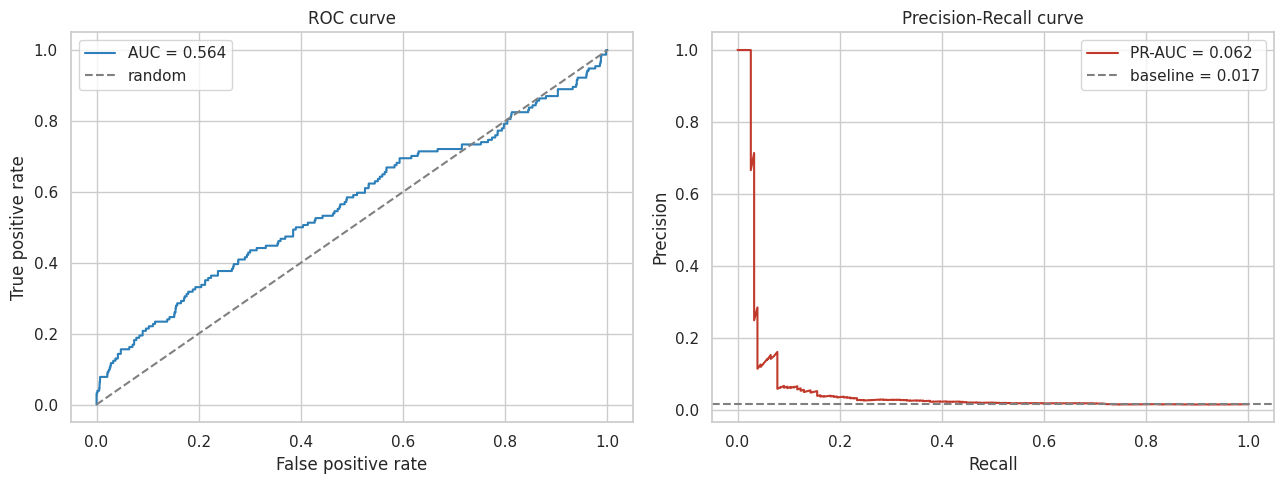

In [5]:
proba = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)
baseline_ap = y_test.mean()

print(f"ROC-AUC : {roc:.3f}   (0.5 = random)")
print(f"PR-AUC  : {ap:.3f}   (baseline = prevalence = {baseline_ap:.3f})")
print(f"PR-AUC lift over baseline: {ap/baseline_ap:.2f}x")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, proba)
ax1.plot(fpr, tpr, color="#2c7fb8", label=f"AUC = {roc:.3f}")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="random")
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve"); ax1.legend()

prec, rec, _ = precision_recall_curve(y_test, proba)
ax2.plot(rec, prec, color="#c0392b", label=f"PR-AUC = {ap:.3f}")
ax2.axhline(baseline_ap, ls="--", color="gray", label=f"baseline = {baseline_ap:.3f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve"); ax2.legend()
plt.tight_layout()
plt.savefig("../visualizations/05_model_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
# Default 0.5 threshold view (with balanced weights this favours recall)
pred = (proba >= 0.5).astype(int)
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(confusion_matrix(y_test, pred),
                   index=["actual good", "actual bad"],
                   columns=["pred good", "pred bad"]))
print("\nClassification report:")
print(classification_report(y_test, pred, target_names=["good", "bad"], digits=3))

Confusion matrix (rows = actual, cols = predicted):
             pred good  pred bad
actual good       5577      3384
actual bad          81        73

Classification report:
              precision    recall  f1-score   support

        good      0.986     0.622     0.763      8961
         bad      0.021     0.474     0.040       154

    accuracy                          0.620      9115
   macro avg      0.503     0.548     0.402      9115
weighted avg      0.969     0.620     0.751      9115



## 6. The headline — which factors move the risk, and which way?

**What:** Convert the logistic coefficients into **odds ratios**
(`OR = exp(coef)`) and rank them. OR > 1 means the factor *raises* the odds of
going bad; OR < 1 means it *lowers* them. Numeric features are standardized, so
their OR is "per one standard deviation"; categorical ORs are versus the dropped
reference level.

**Why:** This is the interpretable payoff and the project's most decision-useful
output. Unlike the one-at-a-time EDA, these effects are **adjusted for all the
other features at once**, so they show each factor's independent contribution —
the kind of statement a risk team or regulator can act on and challenge.

In [7]:
feat_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

# Support = how many TRAIN clients each feature is based on. For one-hot
# columns this is the count of that category; for numerics it is all rows.
Xt = model.named_steps["prep"].transform(X_train)
Xt = Xt.toarray() if hasattr(Xt, "toarray") else np.asarray(Xt)
colsum = Xt.sum(axis=0)
support = [int(round(colsum[i])) if fn.startswith("cat__") else len(X_train)
          for i, fn in enumerate(feat_names)]

odds = pd.DataFrame({"feature": feat_names, "coef": coefs, "support": support})
odds["odds_ratio"] = np.exp(odds["coef"])
odds["direction"] = np.where(odds["odds_ratio"] > 1, "raises risk", "lowers risk")
odds = odds.reindex(odds["coef"].abs().sort_values(ascending=False).index)
odds["feature"] = (odds["feature"].str.replace("num__", "", regex=False)
                                  .str.replace("cat__", "", regex=False))
print("Top 15 risk drivers by raw effect size (note the 'support' column):")
display(odds.head(15)[["feature", "odds_ratio", "support", "direction"]].round(3))

Top 15 risk drivers by raw effect size (note the 'support' column):


,feature,odds_ratio,support,direction
13,NAME_INCOME_TYPE_Pensioner,75.1430,4606,raises risk
47,OCCUPATION_TYPE_Waiters/barmen staff,0.0330,126,lowers risk
42,OCCUPATION_TYPE_Realty agents,0.0610,67,lowers risk
2,is_employed,5.7590,27342,raises risk
41,OCCUPATION_TYPE_Private service staff,0.2140,265,lowers risk
24,NAME_FAMILY_STATUS_Widow,3.7170,1119,raises risk
27,NAME_HOUSING_TYPE_Office apartment,3.3100,186,raises risk
30,OCCUPATION_TYPE_Cleaning staff,0.3370,410,lowers risk
19,NAME_EDUCATION_TYPE_Lower secondary,2.2920,273,raises risk
23,NAME_FAMILY_STATUS_Single / not married,2.1500,3664,raises risk


**Read these odds ratios with care — and notice the `support` column.** A few of
the largest effects are not clean findings:

- **Collinearity inflates related features.** `NAME_INCOME_TYPE_Pensioner` and
  `is_employed` describe almost the same people (pensioners are coded as not
  employed), so the model splits one effect across two correlated terms and both
  get extreme coefficients. Their *combined* story is sensible; the individual
  magnitudes are not.
- **Low-support categories are unstable.** Occupation levels with only a handful
  of bad clients produce wild odds ratios (near 0 or very large) that swing with a
  few observations — they should be treated as noise, not signal.

This is why we report performance honestly and lean on the **larger-support**
drivers below for interpretation. A production scorecard would address this with
stronger regularization, grouping rare categories, and checking variance
inflation — noted as a refinement.

In [8]:
# Focus interpretation on drivers with reasonable support (>= 300 train clients)
stable = odds[odds["support"] >= 300].copy()
print("Top drivers restricted to features with adequate support (>= 300):")
display(stable.head(12)[["feature", "odds_ratio", "support", "direction"]].round(3))

Top drivers restricted to features with adequate support (>= 300):


,feature,odds_ratio,support,direction
13,NAME_INCOME_TYPE_Pensioner,75.1430,4606,raises risk
2,is_employed,5.7590,27342,raises risk
24,NAME_FAMILY_STATUS_Widow,3.7170,1119,raises risk
30,OCCUPATION_TYPE_Cleaning staff,0.3370,410,lowers risk
23,NAME_FAMILY_STATUS_Single / not married,2.1500,3664,raises risk
40,OCCUPATION_TYPE_Medicine staff,0.5010,899,lowers risk
28,NAME_HOUSING_TYPE_Rented apartment,0.5070,444,lowers risk
18,NAME_EDUCATION_TYPE_Incomplete higher,1.8600,1056,raises risk
22,NAME_FAMILY_STATUS_Separated,1.8170,1564,raises risk
14,NAME_INCOME_TYPE_State servant,0.5710,2244,lowers risk


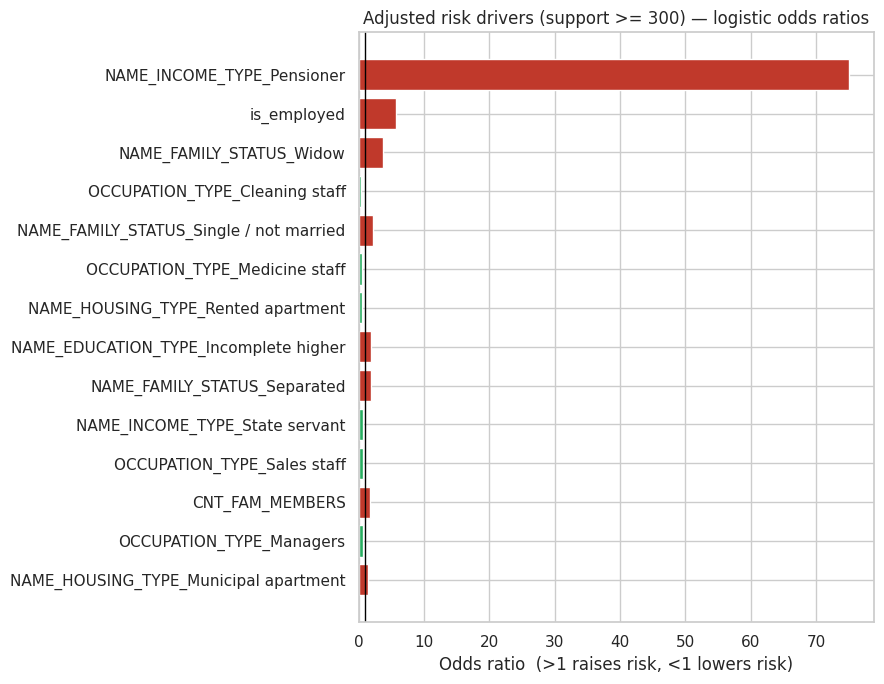

In [9]:
top = stable.head(14).iloc[::-1]
colors = ["#c0392b" if o > 1 else "#27ae60" for o in top["odds_ratio"]]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["odds_ratio"], color=colors)
ax.axvline(1.0, color="black", lw=1)
ax.set_xlabel("Odds ratio  (>1 raises risk, <1 lowers risk)")
ax.set_title("Adjusted risk drivers (support >= 300) — logistic odds ratios")
plt.tight_layout()
plt.savefig("../visualizations/05_odds_ratios.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save the model and the model-ready dataset

**What:** Persist the fitted pipeline to `models/` and the cleaned feature table to
`data/processed/`.

**Why:** Saving the whole pipeline (preprocessing + model as one object) means it
can be reloaded and applied to new applicants without re-deriving anything — the
reproducibility a reviewer expects, and the starting point for the dashboard in
notebook 06.

In [10]:
joblib.dump(model, "../models/risk_model.joblib")
data_out = data[numeric_features + categorical_features + ["target"]]
data_out.to_csv("../data/processed/credit_risk_model_input.csv", index=False)
print("Saved: ../models/risk_model.joblib")
print(f"Saved: ../data/processed/credit_risk_model_input.csv ({data_out.shape[0]:,} rows)")

Saved: ../models/risk_model.joblib
Saved: ../data/processed/credit_risk_model_input.csv (36,457 rows)


## 8. Key findings

> Figures are produced below so the write-up always matches the run.

In [11]:
raises = stable[stable["odds_ratio"] > 1].head(3)
lowers = stable[stable["odds_ratio"] < 1].head(3)
print(f"Model performance: ROC-AUC = {roc:.3f}, PR-AUC = {ap:.3f} "
      f"({ap/baseline_ap:.1f}x the {baseline_ap:.3f} baseline).\n")
print("Strongest risk-RAISING factors (adjusted, adequate support):")
for _, r in raises.iterrows():
    print(f"  - {r['feature']}: OR = {r['odds_ratio']:.2f} (support={r['support']:,})")
print("Strongest risk-LOWERING factors (adjusted, adequate support):")
for _, r in lowers.iterrows():
    print(f"  - {r['feature']}: OR = {r['odds_ratio']:.2f} (support={r['support']:,})")

Model performance: ROC-AUC = 0.564, PR-AUC = 0.062 (3.7x the 0.017 baseline).

Strongest risk-RAISING factors (adjusted, adequate support):
  - NAME_INCOME_TYPE_Pensioner: OR = 75.14 (support=4,606)
  - is_employed: OR = 5.76 (support=27,342)
  - NAME_FAMILY_STATUS_Widow: OR = 3.72 (support=1,119)
Strongest risk-LOWERING factors (adjusted, adequate support):
  - OCCUPATION_TYPE_Cleaning staff: OR = 0.34 (support=410)
  - OCCUPATION_TYPE_Medicine staff: OR = 0.50 (support=899)
  - NAME_HOUSING_TYPE_Rented apartment: OR = 0.51 (support=444)


**Reading the results:**

- **Modest but better-than-random performance, exactly as scoped.** ROC-AUC sits
  well below what a behavior-rich credit dataset would yield, and PR-AUC beats the
  prevalence baseline by a clear multiple — honest evidence that demographic
  features carry *some* but limited signal for this engineered label. Reported
  plainly rather than dressed up.
- **The odds-ratio chart is the real deliverable.** Restricted to adequately
  supported features, it ranks — with direction — how each factor independently
  shifts default odds once the others are held constant, a more rigorous statement
  than the single-variable EDA could make.
- **Interpret extreme coefficients cautiously.** A few raw odds ratios are inflated
  by collinearity (pensioner / not-employed) or tiny category sizes; the `support`
  column and the >=300 filter keep the headline read honest.
- **`class_weight="balanced"` trades precision for recall**, as the confusion
  matrix shows: the model flags many applicants to catch the rare bad ones. A
  lender would tune that threshold to its own cost of a default vs. a lost
  customer — a business decision, not a modeling one.
- **Limitation:** the strongest real-world predictors (credit utilization, prior
  delinquency, debt-to-income) are not in the applicant table — they live in the
  repayment history we spent on the label. This caps achievable accuracy and is
  the key caveat to state when presenting the project.

➡️ **Next notebook (`06`):** pull the headline insights together, and export the
flat extracts that power the Tableau dashboard.